## swiGLU 4 - Retraining (global recovery) analysis

This notebook compares retraining configurations and trainable scopes under a bounded global-recovery budget.

The winning configuration and scope will inform later production-scale retraining experiments.

setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')


PROJECT_ROOT = find_project_root(Path.cwd())
ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'workflows'
    / 'model'
    / 'swiglu-4'
    / 'run-001.json'
)

sns.set_theme(style='whitegrid', context='notebook')

In [3]:
if not ARTIFACT_PATH.is_file():
    raise FileNotFoundError(f'Artifact does not exist: {ARTIFACT_PATH}')

artifact = json.loads(ARTIFACT_PATH.read_text(encoding='utf-8'))
if artifact.get('workflow') != 'swiglu-4':
    raise ValueError('Expected a swiglu-4 artifact')
if artifact.get('schema_version') != 1:
    raise ValueError('Expected schema version 1')
if artifact.get('status') != 'completed':
    raise ValueError(
        f"Artifact is not completed: {artifact.get('status')}"
    )

configuration = artifact['configuration']
results = artifact['results']
print(ARTIFACT_PATH.relative_to(PROJECT_ROOT))

data\results\workflows\model\swiglu-4\run-001.json


In [4]:
run_overview_df = pd.DataFrame([{
    'execution_mode': configuration['execution_mode'],
    'sparsity_key': results['source_state']['sparsity_key'],
    'calibration_pairs': results['source_state']['calibration_pairs'],
    'requested_target_tokens': configuration['recovery']['target_tokens'],
    'effective_batch_tokens': results['data']['effective_batch_tokens'],
    'dense_wikitext_ppl': (
        results['dense_baseline']['wikitext_validation']['perplexity']
    ),
}])
display(run_overview_df)

,execution_mode,sparsity_key,calibration_pairs,requested_target_tokens,effective_batch_tokens,dense_wikitext_ppl
0,scientific,0.5,393216,10000000,2048,14.439586


#### Configuration testing
- learning rate, scheduling
- KL, KL+CE
- weight decay

In [5]:
configuration_stage = results['configuration_testing']
configuration_trajectories = configuration_stage['trajectories']

candidate_rows = []
for trajectory_id, trajectory in configuration_trajectories.items():
    values = trajectory['configuration']
    candidate_rows.append({
        'id': trajectory_id,
        'label': trajectory['label'],
        'learning_rate': values['learning_rate'],
        'scheduler': values['scheduler'],
        'warmup_fraction': values['warmup_fraction'],
        'temperature': values['temperature'],
        'ce_weight': values['ce_weight'],
        'weight_decay': values['weight_decay'],
        'tokens_seen': trajectory['tokens_seen'],
        'trainable_parameters': (
            trajectory['trainable_scope']['trainable_parameters']
        ),
    })

configuration_candidates_df = (
    pd.DataFrame(candidate_rows)
    .sort_values('id')
    .reset_index(drop=True)
)
display(configuration_candidates_df)

,id,label,learning_rate,scheduler,warmup_fraction,temperature,ce_weight,weight_decay,tokens_seen,trainable_parameters
0,C0,swiglu3_baseline,0.00001,constant,0.00,1.0,0.0,0.0,10000384,553648128
1,C1,constant_3e-5,0.00003,constant,0.00,1.0,0.0,0.0,10000384,553648128
2,C2,warmup_cosine_1e-5,0.00001,warmup_cosine,0.01,1.0,0.0,0.0,5001216,553648128
3,C3,warmup_cosine_3e-5,0.00003,warmup_cosine,0.01,1.0,0.0,0.0,5001216,553648128
4,C4,pure_kl_t2,0.00003,constant,0.00,2.0,0.0,0.0,5001216,553648128
5,C5,kl90_ce10_t1,0.00003,constant,0.00,1.0,0.1,0.0,5001216,553648128


In [6]:
def selection_scores_frame(selection, decision):
    selected_id = selection.get('winner', selection.get('promoted'))
    return (
        pd.DataFrame([
            {
                'decision': decision,
                'budget_tokens': selection['budget_tokens'],
                'metric': selection['metric'],
                'candidate': candidate_id,
                'score': score,
                'selected': candidate_id == selected_id,
            }
            for candidate_id, score in selection['scores'].items()
        ])
        .sort_values(['decision', 'score'])
        .reset_index(drop=True)
    )


configuration_selection_scores_df = pd.concat([
    selection_scores_frame(
        configuration_stage['optimizer_selection'],
        'optimizer and scheduler',
    ),
    selection_scores_frame(
        configuration_stage['objective_selection'],
        'training objective',
    ),
], ignore_index=True)

winner = configuration_stage['winner']
winner_configuration = winner['configuration']
configuration_winner_df = pd.DataFrame([{
    'id': winner['id'],
    'label': winner_configuration['label'],
    'target_tokens': winner['target_tokens'],
    'learning_rate': winner_configuration['learning_rate'],
    'scheduler': winner_configuration['scheduler'],
    'temperature': winner_configuration['temperature'],
    'ce_weight': winner_configuration['ce_weight'],
    'weight_decay': winner_configuration['weight_decay'],
    'validation_kl_t1': winner['scores_at_target'][winner['id']],
}])

display(configuration_selection_scores_df)
display(configuration_winner_df)

,decision,budget_tokens,metric,candidate,score,selected
0,optimizer and scheduler,5000000,fixed_recovery_validation_kl_t1,C1,0.284963,True
1,optimizer and scheduler,5000000,fixed_recovery_validation_kl_t1,C3,0.286056,False
2,optimizer and scheduler,5000000,fixed_recovery_validation_kl_t1,C0,0.302777,False
3,optimizer and scheduler,5000000,fixed_recovery_validation_kl_t1,C2,0.306458,False
4,training objective,5000000,fixed_recovery_validation_kl_t1,C1,0.284963,True
5,training objective,5000000,fixed_recovery_validation_kl_t1,C5,0.286076,False
6,training objective,5000000,fixed_recovery_validation_kl_t1,C4,0.313459,False


,id,label,target_tokens,learning_rate,scheduler,temperature,ce_weight,weight_decay,validation_kl_t1
0,C1,constant_3e-5,10000000,0.00003,constant,1.0,0.0,0.0,0.266991


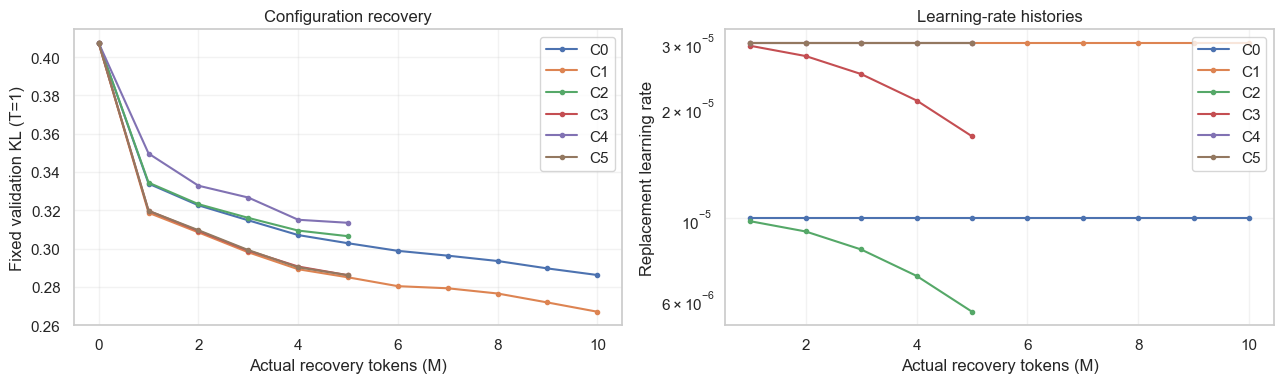

In [7]:
configuration_history_df = pd.DataFrame([
    {'id': trajectory_id, **row}
    for trajectory_id, trajectory in configuration_trajectories.items()
    for row in trajectory['validation_history']
])

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
for trajectory_id, group in configuration_history_df.groupby('id'):
    group = group.sort_values('tokens_seen')
    token_millions = group['tokens_seen'] / 1e6
    axes[0].plot(
        token_millions,
        group['recovery_validation_kl'],
        marker='.',
        label=trajectory_id,
    )
    learning_rate = group['learning_rates'].map(
        lambda values: next(iter(values.values())) if values else None
    )
    axes[1].plot(
        token_millions,
        learning_rate,
        marker='.',
        label=trajectory_id,
    )

axes[0].set(
    xlabel='Actual recovery tokens (M)',
    ylabel='Fixed validation KL (T=1)',
    title='Configuration recovery',
)
axes[1].set(
    xlabel='Actual recovery tokens (M)',
    ylabel='Replacement learning rate',
    title='Learning-rate histories',
)
axes[1].set_yscale('log')
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

In [8]:
configuration_milestone_rows = []
for trajectory_id, trajectory in configuration_trajectories.items():
    for milestone in trajectory['milestones']:
        current = milestone['current']
        configuration_milestone_rows.append({
            'id': trajectory_id,
            'requested_tokens': milestone['requested_tokens'][0],
            'actual_tokens': milestone['actual_tokens'],
            'validation_kl_t1': current['recovery_validation_kl_t1'],
            'wikitext_ppl': (
                current['wikitext_validation']['perplexity']
            ),
            'allocation_ppl': (
                current['allocation_selection']['perplexity']
            ),
        })

configuration_milestones_df = (
    pd.DataFrame(configuration_milestone_rows)
    .sort_values(['requested_tokens', 'validation_kl_t1'])
    .reset_index(drop=True)
)
display(configuration_milestones_df)

,id,requested_tokens,actual_tokens,validation_kl_t1,wikitext_ppl,allocation_ppl
0,C0,0,0,0.407479,28.914613,26.649876
1,C1,0,0,0.407479,28.914613,26.649876
2,C2,0,0,0.407479,28.914613,26.649876
3,C3,0,0,0.407479,28.914613,26.649876
4,C4,0,0,0.407479,28.914613,26.649876
5,C5,0,0,0.407479,28.914613,26.649876
6,C1,1000000,1001472,0.318679,25.842569,24.715526
7,C3,1000000,1001472,0.319717,25.883989,24.782029
8,C5,1000000,1001472,0.319731,25.889067,24.620852
9,C0,1000000,1001472,0.333904,26.530199,25.099499


#### RMSNorm

In [9]:
rms_stage = results['rmsnorm']
rms_trajectories = rms_stage['trajectories']

rms_selection_scores_df = selection_scores_frame(
    rms_stage['selection'],
    'RMSNorm learning-rate multiplier',
)

rms_rows = []
for trajectory_id, trajectory in rms_trajectories.items():
    endpoint = trajectory['endpoint']
    rms_rows.append({
        'id': trajectory_id,
        'label': trajectory['label'],
        'rmsnorm_lr_multiplier': (
            trajectory['configuration']['rmsnorm_learning_rate_multiplier']
        ),
        'actual_tokens': endpoint['actual_tokens'],
        'validation_kl_t1': endpoint['recovery_validation_kl_t1'],
        'wikitext_ppl': (
            endpoint['metrics']['wikitext_validation']['perplexity']
        ),
        'trainable_parameters': (
            trajectory['trainable_scope']['trainable_parameters']
        ),
    })

rms_endpoints_df = (
    pd.DataFrame(rms_rows)
    .sort_values('id')
    .reset_index(drop=True)
)
display(rms_selection_scores_df)
display(rms_endpoints_df)

,decision,budget_tokens,metric,candidate,score,selected
0,RMSNorm learning-rate multiplier,1000000,fixed_recovery_validation_kl_t1,R1,0.317843,True
1,RMSNorm learning-rate multiplier,1000000,fixed_recovery_validation_kl_t1,R2,0.317923,False


,id,label,rmsnorm_lr_multiplier,actual_tokens,validation_kl_t1,wikitext_ppl,trainable_parameters
0,R1,rmsnorm_lr_1x,1.0,10000384,0.266596,24.011471,553693184
1,R2,rmsnorm_lr_10x,10.0,1001472,0.317923,25.839334,553693184


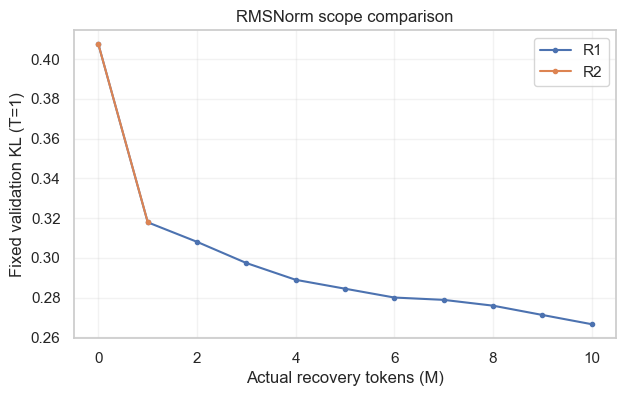

In [10]:
figure, axis = plt.subplots(figsize=(7, 4))
for trajectory_id, trajectory in rms_trajectories.items():
    history_df = (
        pd.DataFrame(trajectory['validation_history'])
        .sort_values('tokens_seen')
    )
    axis.plot(
        history_df['tokens_seen'] / 1e6,
        history_df['recovery_validation_kl'],
        marker='.',
        label=trajectory_id,
    )
axis.set(
    xlabel='Actual recovery tokens (M)',
    ylabel='Fixed validation KL (T=1)',
    title='RMSNorm scope comparison',
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()

In [11]:
rms_parameter_group_rows = []
for trajectory_id, trajectory in rms_trajectories.items():
    for group in trajectory['trainable_scope']['parameter_groups']:
        rms_parameter_group_rows.append({
            'trajectory': trajectory_id,
            'name': group['name'],
            'learning_rate': group['learning_rate'],
            'weight_decay': group['weight_decay'],
            'parameter_tensors': group['parameter_tensors'],
            'parameters': group['parameters'],
        })

rms_parameter_groups_df = pd.DataFrame(rms_parameter_group_rows)
display(rms_parameter_groups_df)

,trajectory,name,learning_rate,weight_decay,parameter_tensors,parameters
0,R1,replacement_mlp,0.00003,0.0,66,553648128
1,R1,post_attention_rmsnorm,0.00003,0.0,22,45056
2,R2,replacement_mlp,0.00003,0.0,66,553648128
3,R2,post_attention_rmsnorm,0.00030,0.0,22,45056


#### LoRA

mlp subset

In [12]:
lora_stage = results['lora']
l1 = lora_stage['trajectories']['L1']

l1_summary_df = pd.DataFrame([{
    'id': 'L1',
    'scope': l1['configuration']['variant'],
    'rank': l1['configuration']['lora_rank'],
    'alpha': l1['configuration']['lora_alpha'],
    'adapter_lr': l1['configuration']['lora_learning_rate'],
    'target_modules': len(l1['trainable_scope']['lora_paths']),
    'trainable_parameters': (
        l1['trainable_scope']['trainable_parameters']
    ),
    'validation_kl_t1': l1['endpoint']['recovery_validation_kl_t1'],
    'wikitext_ppl': (
        l1['endpoint']['metrics']['wikitext_validation']['perplexity']
    ),
}])
display(l1_summary_df)

,id,scope,rank,alpha,adapter_lr,target_modules,trainable_parameters,validation_kl_t1,wikitext_ppl
0,L1,replacement_mlp_lora,16,32.0,0.0001,66,6488064,0.309782,25.566543


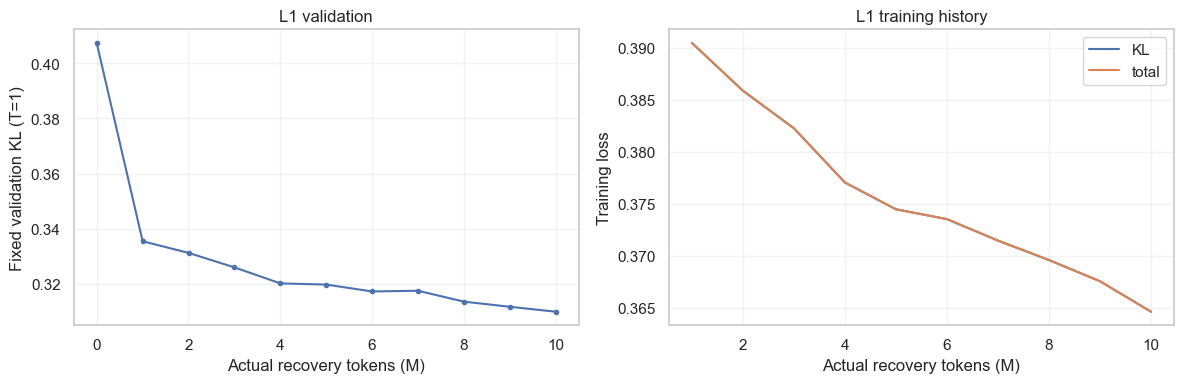

In [13]:
l1_history_df = (
    pd.DataFrame(l1['validation_history'])
    .sort_values('tokens_seen')
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(
    l1_history_df['tokens_seen'] / 1e6,
    l1_history_df['recovery_validation_kl'],
    marker='.',
)
axes[0].set(
    xlabel='Actual recovery tokens (M)',
    ylabel='Fixed validation KL (T=1)',
    title='L1 validation',
)
axes[1].plot(
    l1_history_df['tokens_seen'] / 1e6,
    l1_history_df['mean_train_kl_since_resume'],
    label='KL',
)
axes[1].plot(
    l1_history_df['tokens_seen'] / 1e6,
    l1_history_df['mean_train_loss_since_resume'],
    label='total',
)
axes[1].set(
    xlabel='Actual recovery tokens (M)',
    ylabel='Training loss',
    title='L1 training history',
)
for axis in axes:
    axis.grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

entire model

In [14]:
l2 = lora_stage['trajectories']['L2']

l2_summary_df = pd.DataFrame([{
    'id': 'L2',
    'scope': l2['configuration']['variant'],
    'rank': l2['configuration']['lora_rank'],
    'alpha': l2['configuration']['lora_alpha'],
    'adapter_lr': l2['configuration']['lora_learning_rate'],
    'target_modules': len(l2['trainable_scope']['lora_paths']),
    'trainable_parameters': (
        l2['trainable_scope']['trainable_parameters']
    ),
    'validation_kl_t1': l2['endpoint']['recovery_validation_kl_t1'],
    'wikitext_ppl': (
        l2['endpoint']['metrics']['wikitext_validation']['perplexity']
    ),
    'embeddings_lm_head_tied': (
        l2['trainable_scope']['embedding_and_lm_head'][
            'weight_storage_tied'
        ]
    ),
}])
display(l2_summary_df)

,id,scope,rank,alpha,adapter_lr,target_modules,trainable_parameters,validation_kl_t1,wikitext_ppl,embeddings_lm_head_tied
0,L2,transformer_lora_assisted,16,32.0,0.0001,102,560922624,0.265047,23.986389,True


In [15]:
excluded_modules_df = pd.DataFrame([
    {
        'excluded_module': module,
        'reason': (
            'tied vocabulary table is outside the transformer-recovery scope'
        ),
    }
    for module in l2['trainable_scope']['excluded_modules']
])
lora_selection_scores_df = selection_scores_frame(
    lora_stage['comparison'],
    'LoRA trainable scope',
)
lora_selection_scores_df['embeddings_and_lm_head_excluded'] = (
    lora_stage['comparison']['embeddings_and_lm_head_excluded']
)

display(lora_selection_scores_df)
display(excluded_modules_df)

,decision,budget_tokens,metric,candidate,score,selected,embeddings_and_lm_head_excluded
0,LoRA trainable scope,10000000,fixed_recovery_validation_kl_t1,L2,0.265047,True,True
1,LoRA trainable scope,10000000,fixed_recovery_validation_kl_t1,L1,0.309782,False,True


,excluded_module,reason
0,input_embeddings,tied vocabulary table is outside the transform...
1,lm_head,tied vocabulary table is outside the transform...


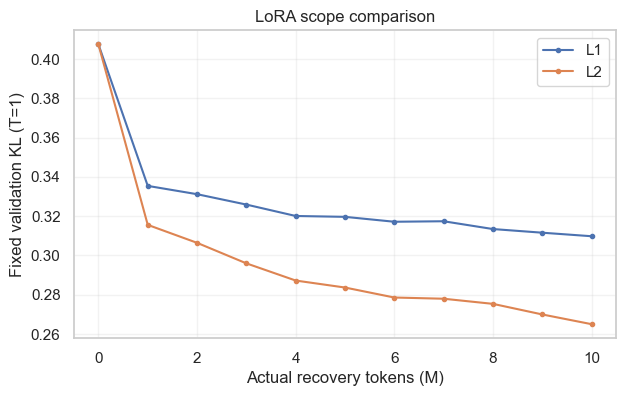

In [16]:
figure, axis = plt.subplots(figsize=(7, 4))
for trajectory_id in ('L1', 'L2'):
    trajectory = lora_stage['trajectories'][trajectory_id]
    history_df = (
        pd.DataFrame(trajectory['validation_history'])
        .sort_values('tokens_seen')
    )
    axis.plot(
        history_df['tokens_seen'] / 1e6,
        history_df['recovery_validation_kl'],
        marker='.',
        label=trajectory_id,
    )
axis.set(
    xlabel='Actual recovery tokens (M)',
    ylabel='Fixed validation KL (T=1)',
    title='LoRA scope comparison',
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()

#### Results

winner comparison

In [17]:
dense_perplexity = (
    results['dense_baseline']['wikitext_validation']['perplexity']
)
pre_recovery_perplexity = (
    results['source_state']['pre_recovery']['wikitext_validation']['perplexity']
)
comparison_ids = ('C0', 'C1', 'R1', 'L1', 'L2')
final_rows_by_id = {
    row['trajectory_id']: row
    for row in results['final_comparison']
}
c0_perplexity = final_rows_by_id['C0']['wikitext_validation_perplexity']
c1_perplexity = final_rows_by_id['C1']['wikitext_validation_perplexity']

comparison_records = []
for trajectory_id in comparison_ids:
    row = final_rows_by_id[trajectory_id]
    perplexity = row['wikitext_validation_perplexity']
    elapsed_seconds = row['elapsed_seconds']
    comparison_records.append({
        'trajectory_id': trajectory_id,
        'role': row['role'],
        'actual_recovery_tokens': row['actual_tokens'],
        'recovery_validation_kl_t1': row['recovery_validation_kl_t1'],
        'wikitext_validation_perplexity': perplexity,
        'ppl_delta_vs_C0': perplexity - c0_perplexity,
        'ppl_delta_vs_C1': perplexity - c1_perplexity,
        'trainable_parameters': row['trainable_parameters'],
        'elapsed_minutes': (
            None
            if elapsed_seconds is None
            else elapsed_seconds / 60
        ),
        'peak_vram_gib': row['peak_vram_gib'],
        'remaining_ppl_gap_over_dense': perplexity - dense_perplexity,
        'gap_recovered_pct': (
            100
            * (pre_recovery_perplexity - perplexity)
            / (pre_recovery_perplexity - dense_perplexity)
        ),
    })

comparison_df = pd.DataFrame(comparison_records)

endpoint_comparison_df = comparison_df[[
    'trajectory_id',
    'role',
    'actual_recovery_tokens',
    'recovery_validation_kl_t1',
    'wikitext_validation_perplexity',
    'ppl_delta_vs_C0',
    'ppl_delta_vs_C1',
]].rename(columns={
    'trajectory_id': 'id',
    'actual_recovery_tokens': 'tokens',
    'recovery_validation_kl_t1': 'validation KL (T=1)',
    'wikitext_validation_perplexity': 'WikiText PPL',
    'ppl_delta_vs_C0': 'PPL delta vs C0',
    'ppl_delta_vs_C1': 'PPL delta vs C1',
})

recovery_gap_df = comparison_df[[
    'trajectory_id',
    'remaining_ppl_gap_over_dense',
    'gap_recovered_pct',
]].rename(columns={
    'trajectory_id': 'id',
    'remaining_ppl_gap_over_dense': 'remaining PPL gap over dense',
    'gap_recovered_pct': 'compression PPL gap recovered (%)',
})

resource_comparison_df = comparison_df[[
    'trajectory_id',
    'trainable_parameters',
    'elapsed_minutes',
    'peak_vram_gib',
]].rename(columns={
    'trajectory_id': 'id',
    'trainable_parameters': 'trainable parameters',
    'elapsed_minutes': 'elapsed minutes',
    'peak_vram_gib': 'peak VRAM GiB',
})

display(endpoint_comparison_df)
display(recovery_gap_df)
display(resource_comparison_df)

,id,role,tokens,validation KL (T=1),WikiText PPL,PPL delta vs C0,PPL delta vs C1
0,C0,reproduced_sw3_baseline,10000384,0.286172,24.686103,0.000000,0.648782
1,C1,configuration_winner,10000384,0.266991,24.037321,-0.648782,0.000000
2,R1,rmsnorm_winner,10000384,0.266596,24.011471,-0.674633,-0.025851
3,L1,replacement_mlp_lora,10000384,0.309782,25.566543,0.880439,1.529221
4,L2,transformer_lora_assisted,10000384,0.265047,23.986389,-0.699714,-0.050932


,id,remaining PPL gap over dense,compression PPL gap recovered (%)
0,C0,10.246518,29.212446
1,C1,9.597736,33.694525
2,R1,9.571885,33.873113
3,L1,11.126957,23.129975
4,L2,9.546803,34.046388


,id,trainable parameters,elapsed minutes,peak VRAM GiB
0,C0,553648128,64.702405,14.299515
1,C1,553648128,64.090630,14.333631
2,R1,553693184,65.507840,14.415507
3,L1,6488064,78.501383,8.491158
4,L2,560922624,101.274765,14.593317


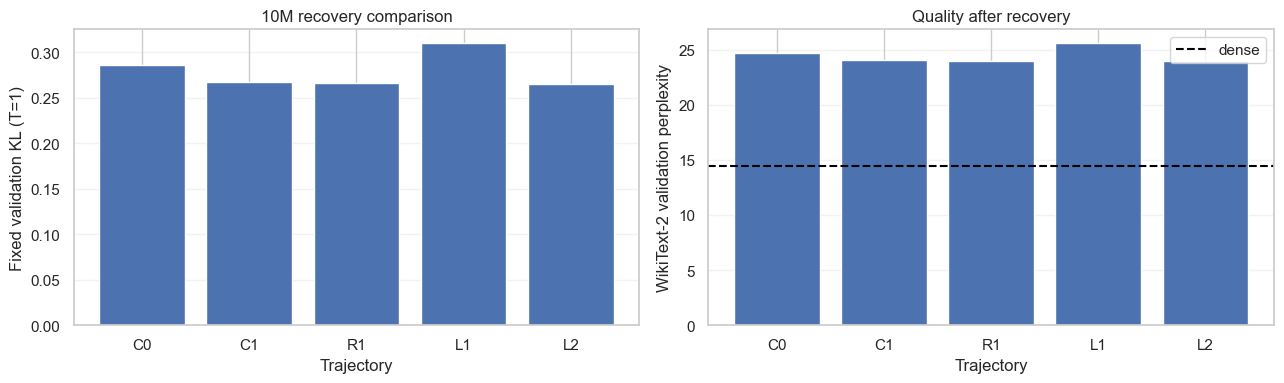

In [18]:
target_millions = configuration['recovery']['target_tokens'] / 1e6
dense_perplexity = (
    results['dense_baseline']['wikitext_validation']['perplexity']
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(
    comparison_df['trajectory_id'],
    comparison_df['recovery_validation_kl_t1'],
)
axes[0].set(
    xlabel='Trajectory',
    ylabel='Fixed validation KL (T=1)',
    title=f'{target_millions:g}M recovery comparison',
)
axes[1].bar(
    comparison_df['trajectory_id'],
    comparison_df['wikitext_validation_perplexity'],
)
axes[1].axhline(
    dense_perplexity,
    color='black',
    linestyle='--',
    label='dense',
)
axes[1].set(
    xlabel='Trajectory',
    ylabel='WikiText-2 validation perplexity',
    title='Quality after recovery',
)
axes[1].legend()
for axis in axes:
    axis.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

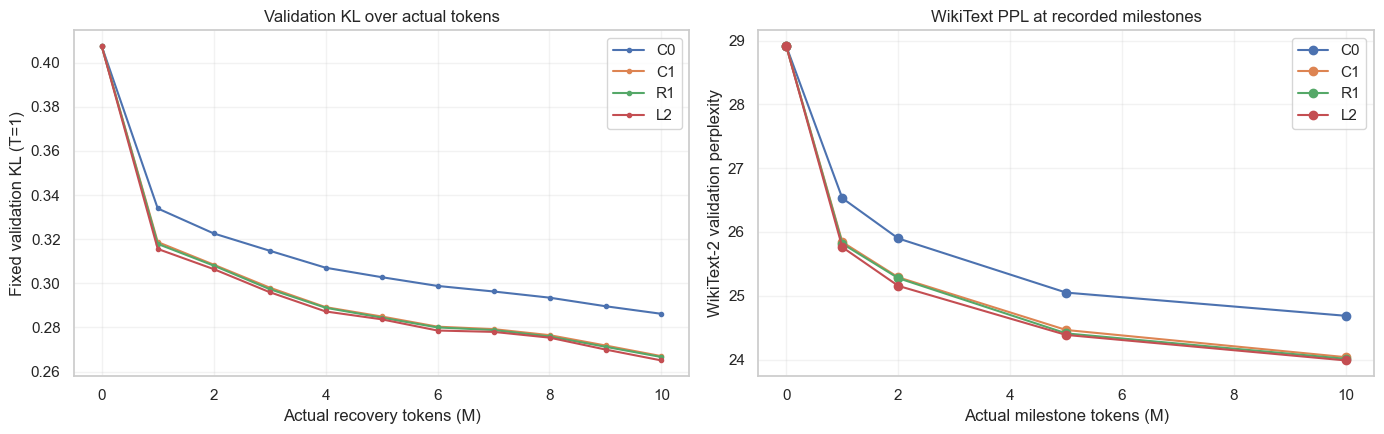

In [19]:
selected_trajectories = {
    'C0': (configuration_stage['trajectories'], 'C0'),
    'C1': (configuration_stage['trajectories'], 'C1'),
    'R1': (rms_stage['trajectories'], 'R1'),
    'L2': (lora_stage['trajectories'], 'L2'),
}

milestone_tokens = {0, 1_000_000, 2_000_000, 5_000_000, 10_000_000}
figure, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
for label, (trajectories, trajectory_id) in selected_trajectories.items():
    trajectory = trajectories[trajectory_id]
    history_df = pd.DataFrame(trajectory['validation_history']).sort_values(
        'tokens_seen'
    )
    axes[0].plot(
        history_df['tokens_seen'] / 1e6,
        history_df['recovery_validation_kl'],
        marker='.',
        label=label,
    )
    milestone_df = pd.DataFrame([
        {
            'requested_tokens': milestone['requested_tokens'][0],
            'actual_tokens': milestone['actual_tokens'],
            'wikitext_validation_perplexity': (
                milestone['current']['wikitext_validation']['perplexity']
            ),
        }
        for milestone in trajectory['milestones']
        if milestone['requested_tokens'][0] in milestone_tokens
    ]).sort_values('actual_tokens')
    axes[1].plot(
        milestone_df['actual_tokens'] / 1e6,
        milestone_df['wikitext_validation_perplexity'],
        marker='o',
        label=label,
    )
axes[0].set(
    xlabel='Actual recovery tokens (M)',
    ylabel='Fixed validation KL (T=1)',
    title='Validation KL over actual tokens',
)
axes[1].set(
    xlabel='Actual milestone tokens (M)',
    ylabel='WikiText-2 validation perplexity',
    title='WikiText PPL at recorded milestones',
)
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

In [20]:
source_artifact_path = Path(
    artifact['provenance']['source_paths']['swiglu_3_artifact']
)
if not source_artifact_path.is_absolute():
    source_artifact_path = PROJECT_ROOT / source_artifact_path
if not source_artifact_path.is_file():
    raise FileNotFoundError(
        f'Provenance-linked SwiGLU-3 artifact does not exist: '
        f'{source_artifact_path}'
    )

swiglu3_artifact = json.loads(
    source_artifact_path.read_text(encoding='utf-8')
)
swiglu3_trajectory = (
    swiglu3_artifact['results']['recovery']['trajectories']['0.5']
)
swiglu3_milestones = {
    milestone['requested_tokens'][0]: milestone
    for milestone in swiglu3_trajectory['milestones']
}
swiglu3_10m = swiglu3_milestones[10_000_000]
swiglu3_100m = swiglu3_milestones[100_000_000]
selected_evaluation = swiglu3_trajectory['post_recovery_model_evaluation']

budget_context_records = [
    {
        'trajectory': 'SwiGLU-3 50%',
        'budget context': '10M milestone current',
        'tokens': swiglu3_10m['actual_tokens'],
        'validation_kl_t1': swiglu3_10m['current']['recovery_validation_kl'],
        'wikitext_ppl': (
            swiglu3_10m['current']['wikitext_validation']['perplexity']
        ),
    },
    {
        'trajectory': 'SwiGLU-3 50%',
        'budget context': 'selected checkpoint under 100M budget',
        'tokens': swiglu3_trajectory['selected_checkpoint']['tokens_seen'],
        'validation_kl_t1': selected_evaluation['recovery_validation_kl'],
        'wikitext_ppl': (
            selected_evaluation['wikitext_validation']['perplexity']
        ),
    },
    {
        'trajectory': 'SwiGLU-3 50%',
        'budget context': '100M endpoint current',
        'tokens': swiglu3_100m['actual_tokens'],
        'validation_kl_t1': swiglu3_100m['current']['recovery_validation_kl'],
        'wikitext_ppl': (
            swiglu3_100m['current']['wikitext_validation']['perplexity']
        ),
    },
]
for label, trajectories, trajectory_id in (
    ('C1', configuration_stage['trajectories'], 'C1'),
    ('R1', rms_stage['trajectories'], 'R1'),
    ('L2', lora_stage['trajectories'], 'L2'),
):
    trajectory = trajectories[trajectory_id]
    milestone = next(
        milestone
        for milestone in trajectory['milestones']
        if milestone['requested_tokens'][0] == 10_000_000
    )
    budget_context_records.append({
        'trajectory': f'SwiGLU-4 {label}',
        'budget context': '10M milestone current',
        'tokens': milestone['actual_tokens'],
        'validation_kl_t1': milestone['current']['recovery_validation_kl'],
        'wikitext_ppl': (
            milestone['current']['wikitext_validation']['perplexity']
        ),
    })

budget_context_df = pd.DataFrame(budget_context_records)
budget_context_df['remaining_ppl_gap_over_dense'] = (
    budget_context_df['wikitext_ppl'] - dense_perplexity
)
budget_context_df['gap_recovered_pct'] = (
    100
    * (pre_recovery_perplexity - budget_context_df['wikitext_ppl'])
    / (pre_recovery_perplexity - dense_perplexity)
)
display(budget_context_df)

,trajectory,budget context,tokens,validation_kl_t1,wikitext_ppl,remaining_ppl_gap_over_dense,gap_recovered_pct
0,SwiGLU-3 50%,10M milestone current,10000384,0.286172,24.686103,10.246518,29.212446
1,SwiGLU-3 50%,selected checkpoint under 100M budget,95000576,0.219773,22.146371,7.706786,46.758057
2,SwiGLU-3 50%,100M endpoint current,100000000,0.220696,22.090755,7.651169,47.142283
3,SwiGLU-4 C1,10M milestone current,10000384,0.266991,24.037321,9.597736,33.694525
4,SwiGLU-4 R1,10M milestone current,10000384,0.266596,24.011471,9.571885,33.873113
5,SwiGLU-4 L2,10M milestone current,10000384,0.265047,23.986389,9.546803,34.046388


C1 is the controlled configuration winner and provides the decisive improvement over C0. R1 is the practical optional extension because its gain is small but its additional cost is negligible. L2 is the raw 10M metric winner, but its small gain and materially slower runtime do not justify it as the default. A longer recovery budget remains a larger lever than these scope extensions.

In [21]:
runtime_df = pd.DataFrame(results['runtime'])
runtime_df['minutes'] = runtime_df['seconds'] / 60
runtime_df['hours'] = runtime_df['seconds'] / 3600
display(runtime_df)

,stage,seconds,minutes,hours
0,load_model_data_and_source_state,19.297646,0.321627,0.005360
1,configuration_testing,15591.346513,259.855775,4.330930
2,rmsnorm,4377.436489,72.957275,1.215955
3,lora,10811.896022,180.198267,3.003304


In [22]:
provenance_df = pd.DataFrame([
    {
        'field': 'artifact status',
        'value': artifact['status'],
    },
    {
        'field': 'source artifact',
        'value': artifact['provenance']['source_paths']['swiglu_3_artifact'],
    },
    {
        'field': 'source SHA-256',
        'value': artifact['provenance']['source_sha256']['swiglu_3_artifact'],
    },
    {
        'field': 'packed-token fingerprint',
        'value': results['data']['packed_token_cache']['fingerprint'],
    },
    {
        'field': 'persistent weight assets',
        'value': artifact['storage']['persistent_weight_assets'],
    },
    {
        'field': 'temporary scratch removed',
        'value': artifact['storage']['temporary_scratch_removed'],
    },
])
with pd.option_context('display.max_colwidth', None):
    display(provenance_df)

,field,value
0,artifact status,completed
1,source artifact,data/results/workflows/model/swiglu-3/run-001.json
2,source SHA-256,105e6e0588fb0281cfa382d5c47daa976c1ab00dbf504a132676cf037364d3da
3,packed-token fingerprint,4290c435bf4254c1c2aa6e7cd5927e5d176aa46685e4b6369e6ef92c7fc94006
4,persistent weight assets,False
5,temporary scratch removed,True


In [23]:
operator_state_files_df = (
    pd.DataFrame(results['data']['operator_state_files'])
    .T
    .rename_axis('layer')
    .reset_index()
)
operator_state_files_df['source_file'] = operator_state_files_df[
    'source_path'
].map(lambda path: Path(path).name)
operator_state_files_df['size_mib'] = (
    operator_state_files_df['bytes'] / 1024**2
)
operator_state_files_df = operator_state_files_df[[
    'layer',
    'source_file',
    'replacement_width',
    'size_mib',
]]
display(operator_state_files_df)

,layer,source_file,replacement_width,size_mib
0,1,layer-01.pt,5179,121.384892
1,2,layer-02.pt,4878,114.330205
2,3,layer-03.pt,4716,110.53333
3,4,layer-04.pt,4183,98.041142
4,5,layer-05.pt,3782,88.642705
5,6,layer-06.pt,3567,83.603642
6,7,layer-07.pt,3987,93.447392
7,8,layer-08.pt,4369,102.400517
8,9,layer-09.pt,3342,78.330205
9,10,layer-10.pt,2857,66.963017
